# CdV Regimes with diffusion maps

In [1]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib

importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [ ]:
from cdv_utils import (load_d, plot_lifetime_distributions_lines,
                       calculate_escape_times)

In [3]:
dims = 6
sample_num = 200000
state_vector = load_d(
    "./cdv_model/dataOro20_sigma0p0000.bin", dims, sample_num)

FileNotFoundError: [Errno 2] No such file or directory: './cdv_model/dataOro20_sigma0p0000.bin'

## Regimes from deterministic dynamics

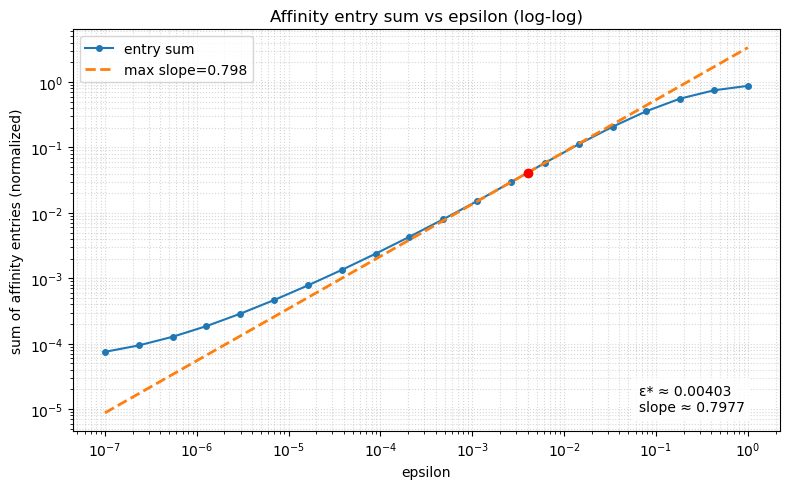

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


def affinity_entry_sum(X, epsilon, chunk=1000):
    """sum_{i,j} exp(-||x_i-x_j||^2 / epsilon)"""
    X = np.asarray(X)
    n = X.shape[0]
    total = 0.0
    for i in range(0, n, chunk):
        d2 = cdist(X[i:i+chunk], X, metric='sqeuclidean')
        total += np.exp(-d2 / epsilon).sum()
    return float(total)


# --- user-defined / manual settings ---
# assume `state_vector` exists (samples x features); subsample as desired:
X = state_vector[::10]        # change or remove subsampling as needed

# manually set epsilons (example: log-spaced around data scale)
# <- edit this array if you want explicit values
eps_vals = np.logspace(-7, 0, 20)

# compute sums
sums = np.array([affinity_entry_sum(X, eps, chunk=1000)
                for eps in eps_vals]) / X.shape[0]**2

# compute log-log slopes and find maximum
logx = np.log10(eps_vals)
logy = np.log10(sums)
slopes = np.diff(logy) / np.diff(logx)
imax = int(np.argmax(slopes))
slope_max = slopes[imax]
eps_at_max = np.sqrt(eps_vals[imax] * eps_vals[imax+1])
# line (in log space) anchored at midpoint
logx_mid = 0.5*(logx[imax]+logx[imax+1])
logy_mid = 0.5*(logy[imax]+logy[imax+1])
x_line_log = np.linspace(logx[0], logx[-1], 300)
y_line_log = slope_max*(x_line_log - logx_mid) + logy_mid

# plot
plt.figure(figsize=(8, 5))
plt.loglog(eps_vals, sums, '-o', markersize=4, label='entry sum')
plt.loglog(10**x_line_log, 10**y_line_log, '--',
           linewidth=2, label=f'max slope={slope_max:.3f}')
plt.scatter([eps_at_max], [
            10**(slope_max*(logx_mid-logx_mid)+logy_mid)], color='red', zorder=10)
plt.xlabel('epsilon')
plt.ylabel('sum of affinity entries (normalized)')
plt.title('Affinity entry sum vs epsilon (log-log)')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.text(0.8, 0.05, f'ε* ≈ {eps_at_max:.3g}\nslope ≈ {slope_max:.4f}', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
plt.tight_layout()
plt.show()

Subsampled 20000 samples (every 10th of 200000).
Cluster counts: [15287  4712]


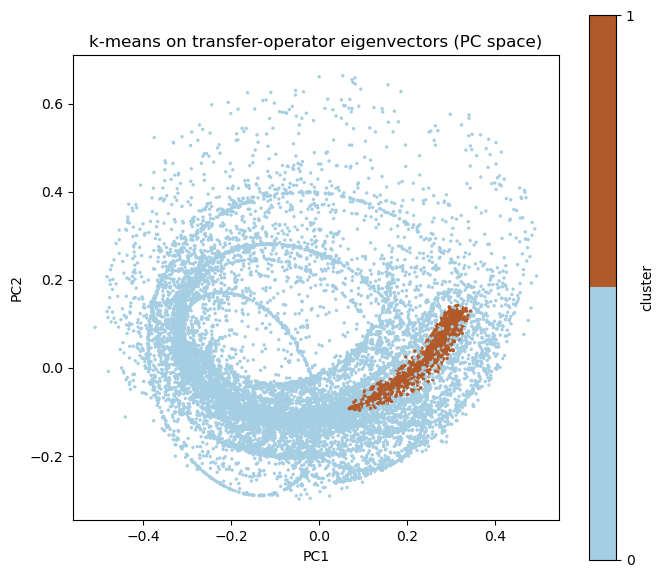

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

epsilon = 1e-3
subsample_step = 10
n_eig = 12
n_clusters = 2
n_init = 10
eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
random_state = 0

# --- subsample (every 20th sample, like the original workflow) ---
n_total = state_vector.shape[0]
inds = np.arange(0, n_total, subsample_step)
X_sub = state_vector[inds, :]        # shape (n_subsamples, n_features)
print(
    f"Subsampled {X_sub.shape[0]} samples (every {subsample_step}th of {n_total}).")

# --- build diffusion-maps matrix (expects samples x features) ---
DMM, A = diffusion_maps_matrix(X_sub, epsilon)

# --- compute clusters from TO ---
res = compute_clusters_from_TO(DMM,
                               n_eig=n_eig,
                               n_clusters=n_clusters,
                               n_init=n_init,
                               eig_indices=eig_indices,
                               random_state=random_state)

labels = res['labels']               # shape (n_subsamples - 1,)
print("Cluster counts:", np.bincount(labels))

# --- PCA for visualization ---
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(X_sub)   # shape (n_subsamples, 3)

# --- align with labels: drop last row to match n_subsamples - 1 ---
PC_scores = PC_scores[:-1, :]

# --- scatter plot PC1 vs PC2 colored by cluster label ---
plt.figure(figsize=(7, 6))
num_clusters = len(np.unique(labels))
cmap = plt.get_cmap("Paired", num_clusters)
sc = plt.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=labels, s=6, linewidth=0, cmap=cmap)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('k-means on transfer-operator eigenvectors (PC space)')
cbar = plt.colorbar(sc, ticks=range(num_clusters))
cbar.set_label('cluster')
cbar.set_ticklabels(range(num_clusters))
plt.tight_layout()
plt.show()

### Compare with stochastic CdV

In [14]:
import glob
import re
import matplotlib.pyplot as plt

results = []

# --- include base case ---
# results.append({
#     "sigma": 0.0,
#     "coords": PC_scores,   # base trajectory coordinates
#     "labels": labels           # base labels
# })

# --- loop over files ---
for fname in sorted(glob.glob("./cdv_model/dataOro20_sigma*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    if not match:
        continue
    sigma_str = match.group(1).replace("p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)

    # load data
    sig_data = load_d(fname, dims, sample_num)

    # classify
    labels_new = classify_new_trajectory(
        X_sub[:-1, :], labels, sig_data, k=20, threshold=0.5)

    # PCA
    coords = pca.transform(sig_data)

    results.append({
        "sigma": sigma_val,
        "coords": coords,
        "labels": labels_new
    })

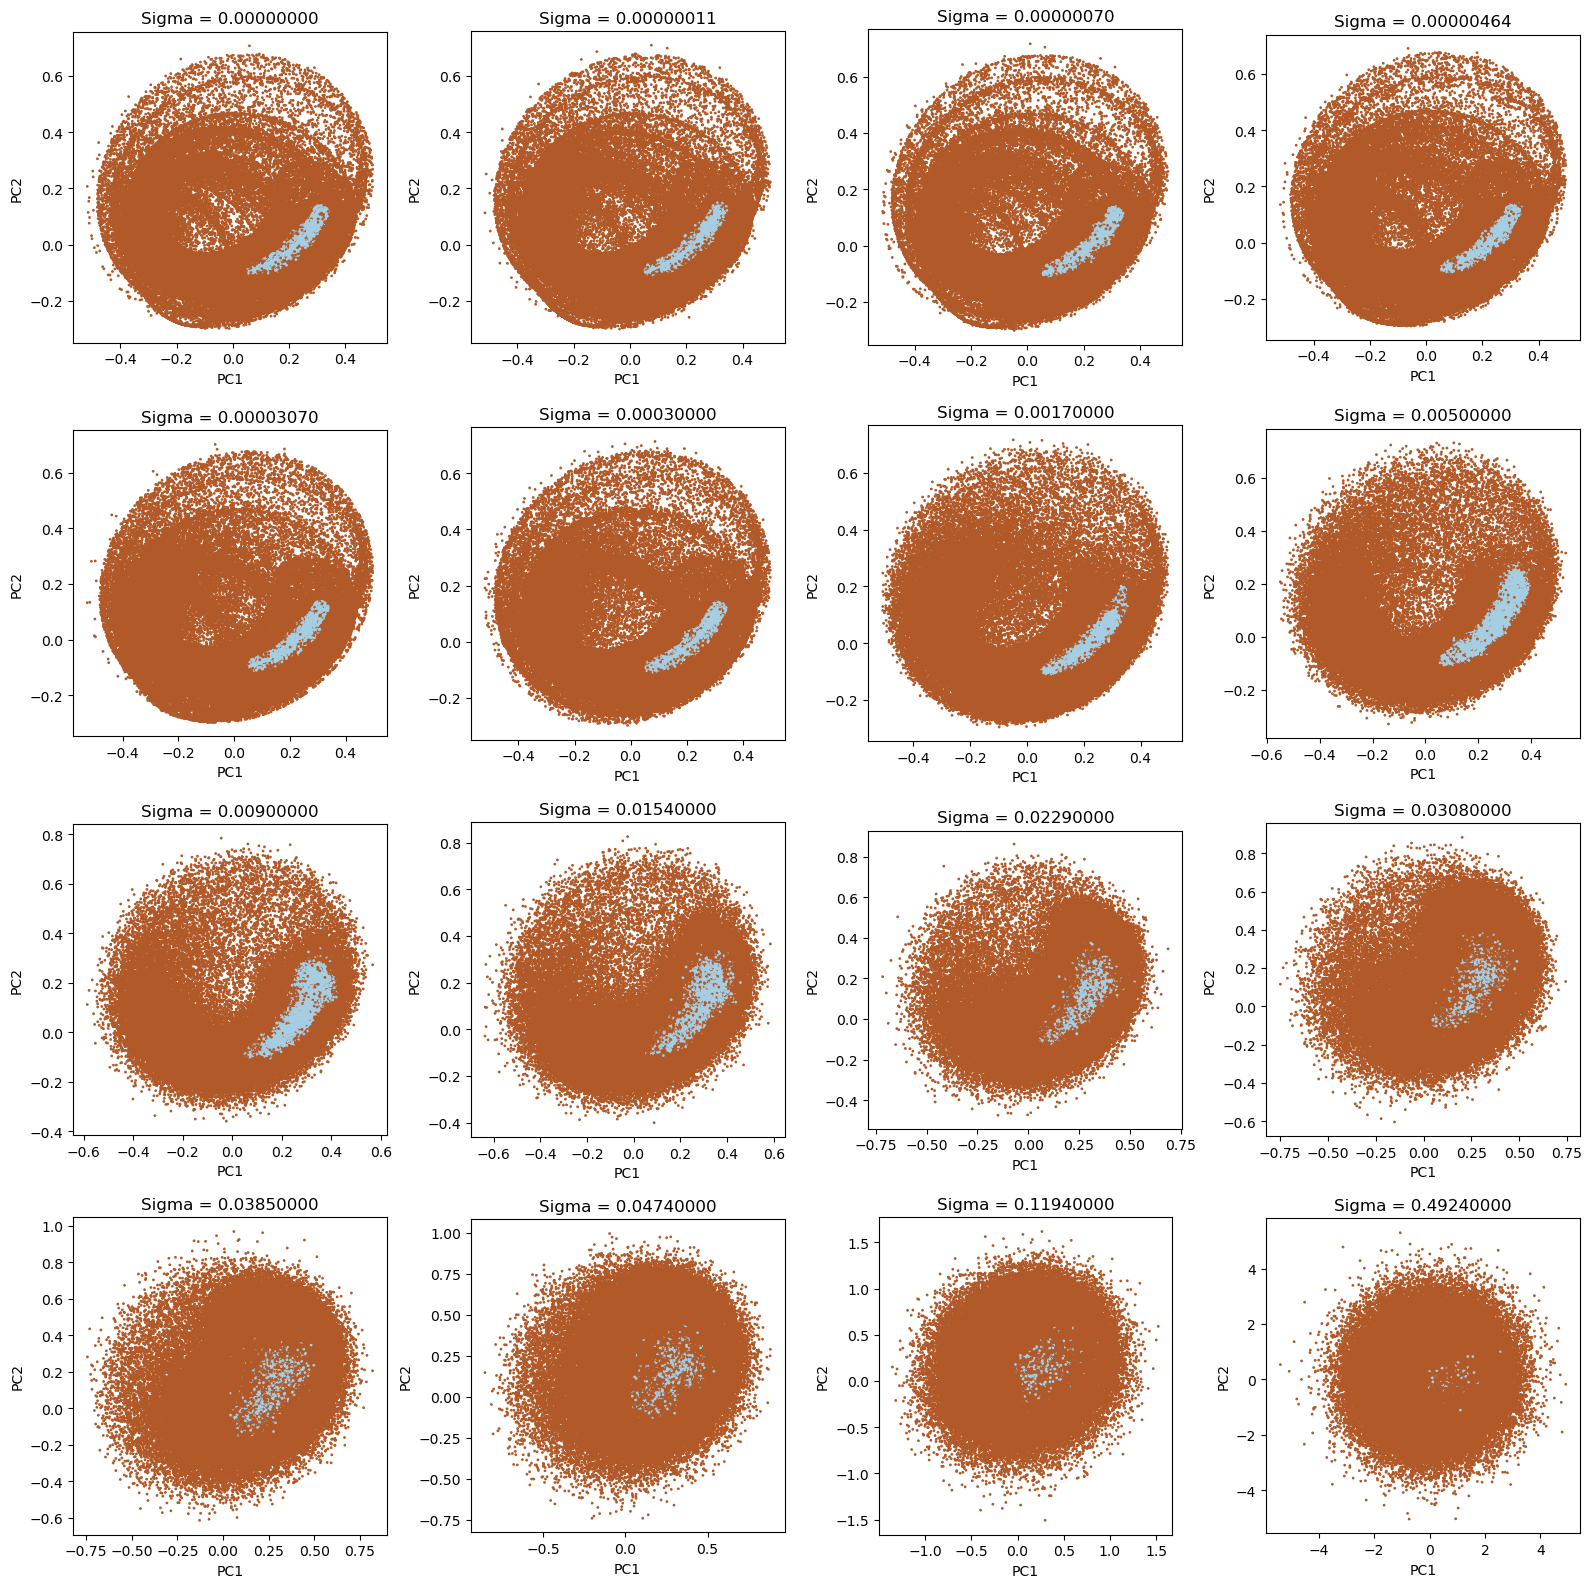

In [18]:

# --- plotting ---
ncols = 4
nrows = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

for ax, res in zip(axes, results[::8]):
    sc = ax.scatter(res["coords"][:, 0], res["coords"][:, 1],
                    c=res["labels"], s=1, cmap=cmap)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Sigma = {res['sigma']:.8f}")

# fig.colorbar(sc, ax=axes.tolist(), label="cluster label")
plt.tight_layout()
plt.show()

In [19]:
from collections import defaultdict
import numpy as np

# escape_results[regime][sigma] = list of lifetimes
escape_results = defaultdict(lambda: defaultdict(list))

for res in results:
    sigma = res["sigma"]
    labels_seq = res["labels"]

    esc_dict = calculate_escape_times(labels_seq, dt=1.0)
    for regime, times in esc_dict.items():
        escape_results[regime][sigma].extend(times)

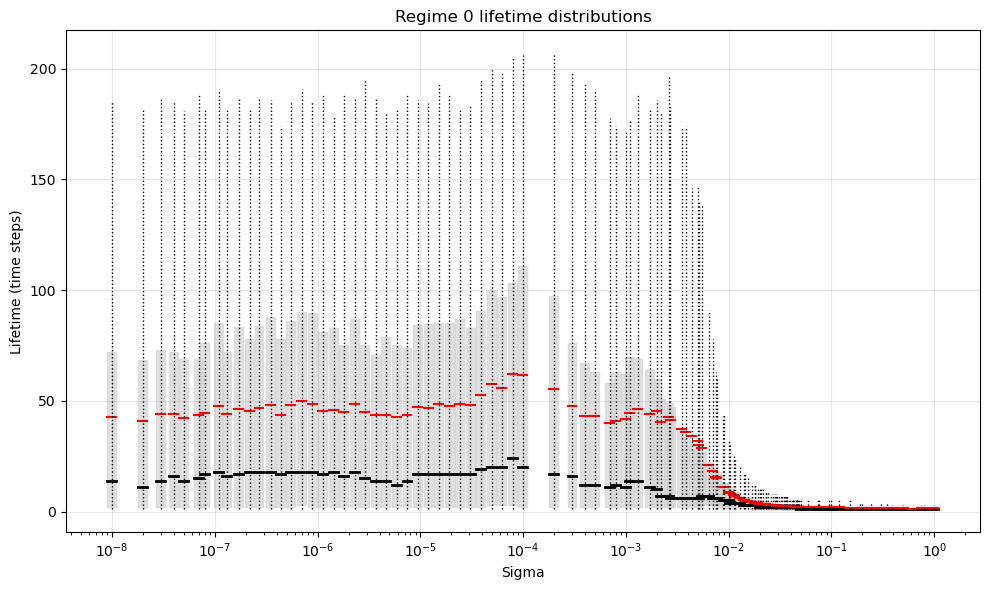

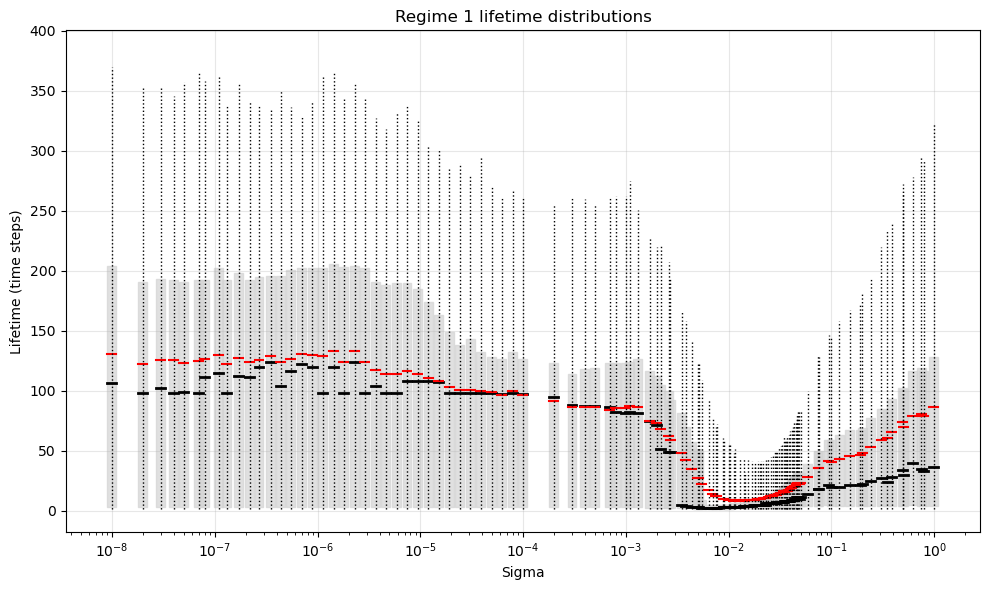

In [20]:
import matplotlib.pyplot as plt


def plot_lifetime_distributions(escape_results, regime, logx=True):
    sigmas = sorted(escape_results[regime].keys())

    fig, ax = plt.subplots(figsize=(10, 6))

    for sigma in sigmas:
        data = np.array(escape_results[regime][sigma])
        if len(data) == 0:
            continue

        q0, q25, q50, q75, q95 = np.percentile(data, [0, 25, 50, 75, 95])
        mean_val = np.mean(data)

        # shaded IQR
        ax.fill_between([sigma*0.9, sigma*1.1], q25, q75,
                        color="lightgray", alpha=0.7)

        # median (black thick line)
        ax.plot([sigma*0.9, sigma*1.1], [q50, q50], color="black", linewidth=2)

        # mean (red line)
        ax.plot([sigma*0.9, sigma*1.1], [mean_val, mean_val],
                color="red", linewidth=1.5)

        # 0th and 95th percentile (dotted black lines)
        ax.plot([sigma, sigma], [q0, q95], color="black",
                linestyle=":", linewidth=1)

    ax.set_xlabel("Sigma")
    ax.set_ylabel("Lifetime (time steps)")
    ax.set_title(f"Regime {regime} lifetime distributions")
    if logx:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Example usage:
plot_lifetime_distributions(escape_results, regime=0, logx=True)
plot_lifetime_distributions(escape_results, regime=1, logx=True)

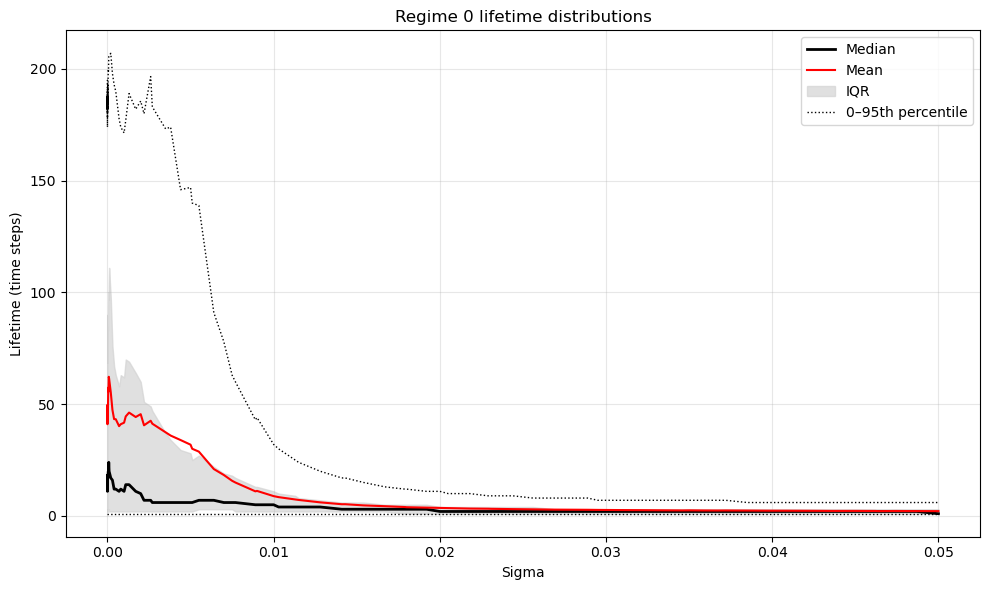

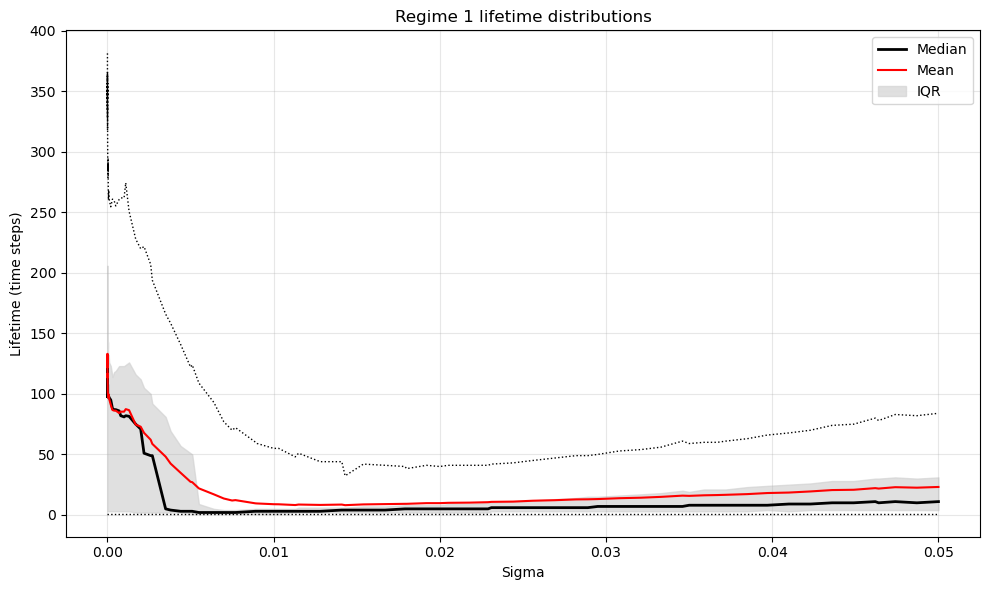

In [22]:
sigma_min = 0.0
sigma_max = 0.05
plot_lifetime_distributions_lines({
    regime: {s: vals for s, vals in escape_results[regime].items()
             if sigma_min <= s <= sigma_max}
    for regime in escape_results
}, regime=0, logx=False)
plot_lifetime_distributions_lines({
    regime: {s: vals for s, vals in escape_results[regime].items()
             if sigma_min <= s <= sigma_max}
    for regime in escape_results
}, regime=1, logx=False)

# Regimes defined by stochastic trajectory

In [ ]:
clustering_results = []

# --- loop over all sigma files ---
for fname in sorted(glob.glob("./cdv_model/dataOro20_sigma*.bin")):
    # extract sigma from filename
    match = re.search(r"sigma([0-9p]+)", fname)
    if not match:
        continue
    sigma_str = match.group(1).replace("p", ".")
    sigma_val = float(sigma_str)
    if sigma_val <= 0.035:
        print(f"Processing sigma = {sigma_val:.6f}")

        # --- load state vector ---
        sig_data = load_d(fname, dims, sample_num)
        X_sub = sig_data[inds, :]  # (n_subsamples, n_features)

        # --- diffusion maps ---
        DMM, A = diffusion_maps_matrix(X_sub, epsilon)

        # --- compute clusters from TO ---
        res = compute_clusters_from_TO(
            DMM,
            n_eig=n_eig,
            n_clusters=n_clusters,
            n_init=n_init,
            eig_indices=eig_indices,
            random_state=random_state
        )
        labels = res["labels"]

        # --- PCA for visualization ---
        PC_scores = pca.transform(X_sub)
        PC_scores = PC_scores[:-1, :]  # align with labels

        # --- save results ---
        clustering_results.append({
            "sigma": sigma_val,
            "labels": labels,
            "PC_scores": PC_scores,
        })

Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000000
Processing sigma = 0.000001
Processing sigma = 0.000001
Processing sigma = 0.000001
Processing sigma = 0.000001
Processing sigma = 0.000001
Processing sigma = 0.000002
Processing sigma = 0.000002
Processing sigma = 0.000003
Processing sigma = 0.000004
Processing sigma = 0.000005
Processing sigma = 0.000006
Processing sigma = 0.000007
Processing sigma = 0.000009
Processing sigma = 0.000012
Processing sigma = 0.000015
Processing sigma = 0.000019
Processing sigma = 0.000024
Processing sigma = 0.000031
Processing sigma = 0.000039
Processing sigma = 0.000049
Processing sigma = 0

In [114]:
import pickle

with open("clustering_results.pkl", "wb") as f:
    pickle.dump(clustering_results, f)

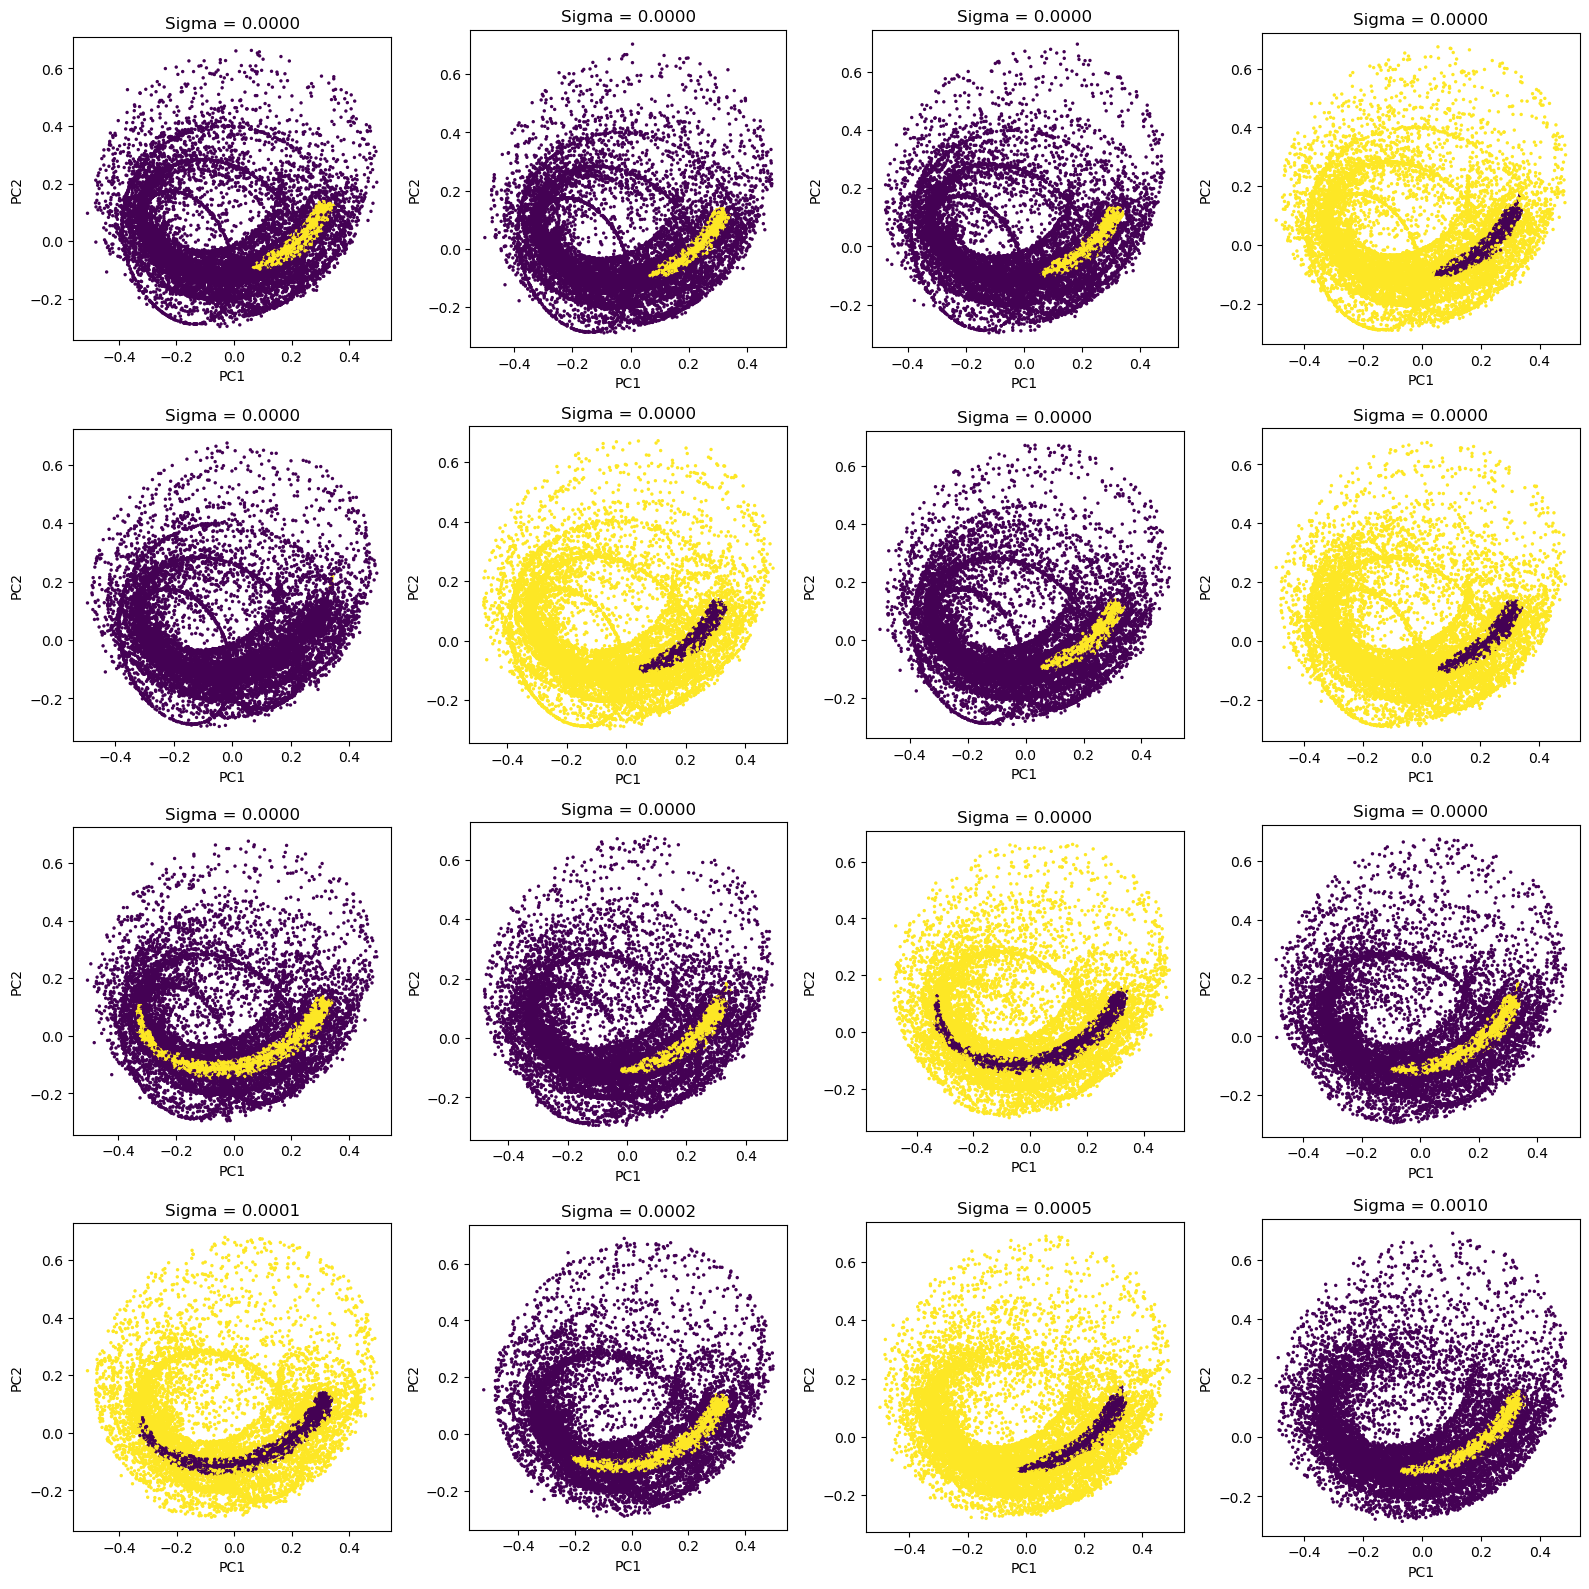

In [115]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

for ax, res in zip(axes, clustering_results[::3]):
    sc = ax.scatter(res["PC_scores"][:, 0], res["PC_scores"][:, 1],
                    c=res["labels"], s=6, linewidth=0)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Sigma = {res['sigma']:.4f}")

# fig.colorbar(sc, ax=axes.tolist(), label="cluster label")
plt.tight_layout()
plt.show()

In [ ]:
clustering_results = []

# --- loop over all sigma files ---
for fname in sorted(glob.glob("./cdv_model/dataOro20_sigma*.bin")):
    # extract sigma from filename
    match = re.search(r"sigma([0-9p]+)", fname)
    if not match:
        continue
    sigma_str = match.group(1).replace("p", ".")
    sigma_val = float(sigma_str)
    if sigma_val <= 0.015 and sigma_val >= 0.0005:
        print(f"Processing sigma = {sigma_val:.6f}")

        # --- load state vector ---
        sig_data = load_d(fname, dims, sample_num)
        X_sub = sig_data[inds, :]  # (n_subsamples, n_features)

        # --- diffusion maps ---
        if sigma_val == 0.0:
            epsilon = 1e-3  # fallback to small positive value
        else:
            epsilon = sigma_val

        DMM, A = diffusion_maps_matrix(X_sub, epsilon)

        # --- compute clusters from TO ---
        res = compute_clusters_from_TO(
            DMM,
            n_eig=n_eig,
            n_clusters=n_clusters,
            n_init=n_init,
            eig_indices=eig_indices,
            random_state=random_state
        )
        labels = res["labels"]

        PC_scores = pca.transform(X_sub)
        PC_scores = PC_scores[:-1, :]  # align with labels

        # --- save results ---
        clustering_results.append({
            "sigma": sigma_val,
            "labels": labels,
            "PC_scores": PC_scores,
        })

Processing sigma = 0.000500
Processing sigma = 0.000700
Processing sigma = 0.000800
Processing sigma = 0.001000
Processing sigma = 0.001100
Processing sigma = 0.001300
Processing sigma = 0.001700
Processing sigma = 0.002000
Processing sigma = 0.002200
Processing sigma = 0.002600
Processing sigma = 0.002700
Processing sigma = 0.003500
Processing sigma = 0.003800
Processing sigma = 0.004400
Processing sigma = 0.005000
Processing sigma = 0.005100
Processing sigma = 0.005500
Processing sigma = 0.006400
Processing sigma = 0.007000
Processing sigma = 0.007500
Processing sigma = 0.007700
Processing sigma = 0.008900
Processing sigma = 0.009000
Processing sigma = 0.010000
Processing sigma = 0.010300
Processing sigma = 0.011300
Processing sigma = 0.011500
Processing sigma = 0.012800
Processing sigma = 0.014100
Processing sigma = 0.014300


In [125]:
with open("clustering_results_vareps.pkl", "wb") as f:
    pickle.dump(clustering_results, f)

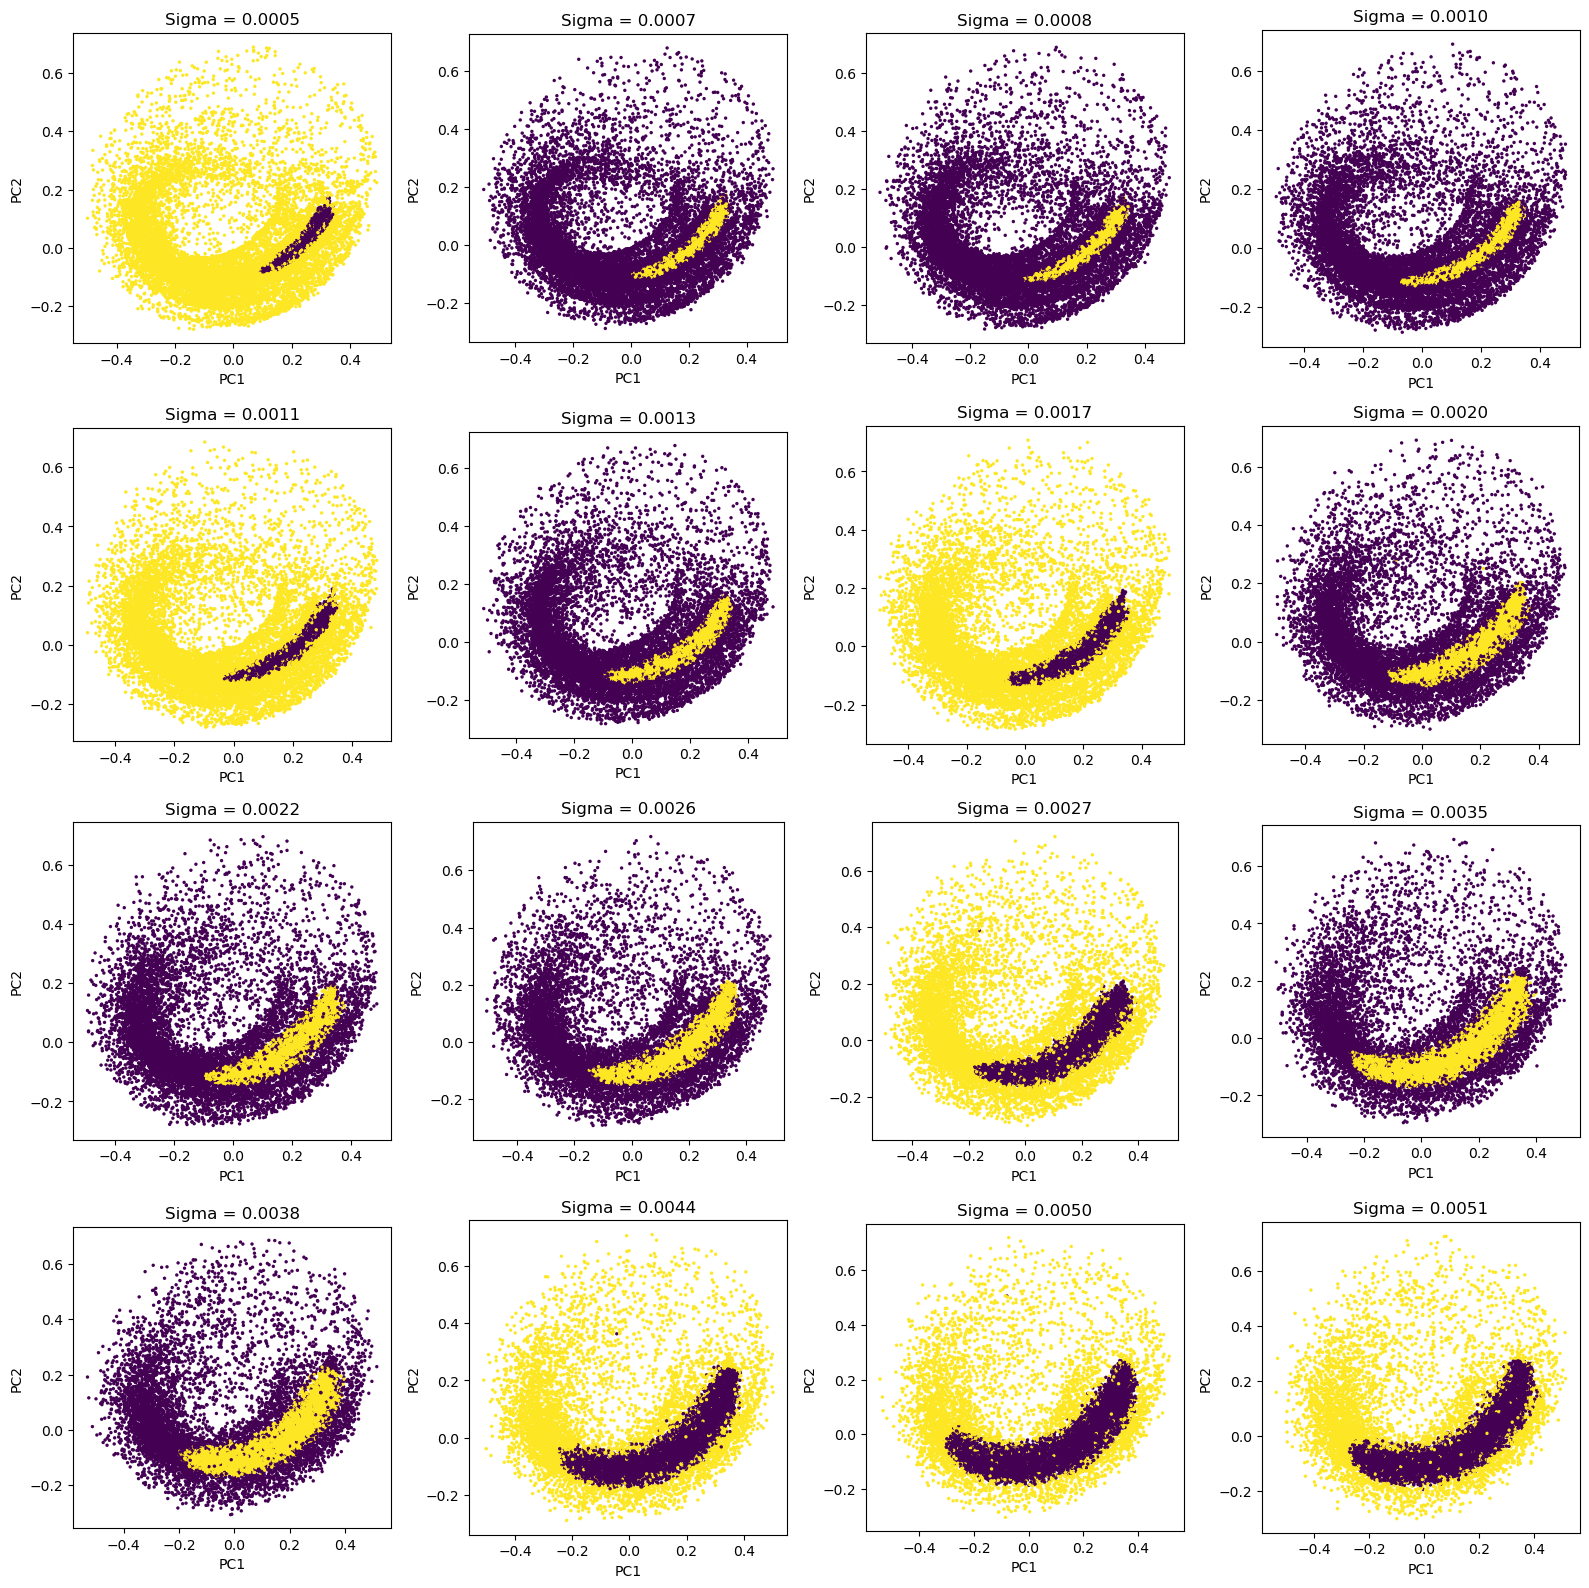

In [126]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

for ax, res in zip(axes, clustering_results):
    sc = ax.scatter(res["PC_scores"][:, 0], res["PC_scores"][:, 1],
                    c=res["labels"], s=6, linewidth=0)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Sigma = {res['sigma']:.4f}")

# fig.colorbar(sc, ax=axes.tolist(), label="cluster label")
plt.tight_layout()
plt.show()

## **Use $\sigma \approx \epsilon^{\ast} \approx 10^{-3}$**

In [ ]:
# If the above hast been run, use this
# find matching entry
entry = next(
    r for r in clustering_results
    if np.isclose(r["sigma"], epsilon, rtol=1e-10, atol=1e-12)
)
labels = entry["labels"]
PC_scores = entry["PC_scores"]

fname = "./cdv_model/dataOro20_sigma" + \
    f"{epsilon:.4f}".replace(".", "p") + ".bin"

X_sub = load_d(fname, dims, sample_num)[inds, :]

In [ ]:
# Otherwise, this
X_sub = state_vector[inds, :]  # (n_subsamples, n_features)

DMM, A = diffusion_maps_matrix(X_sub, epsilon)

# --- compute clusters from TO ---
res = compute_clusters_from_TO(
    DMM,
    n_eig=n_eig,
    n_clusters=n_clusters,
    n_init=n_init,
    eig_indices=eig_indices,
    random_state=random_state
)
labels = res["labels"]

PC_scores = pca.transform(X_sub)
PC_scores = PC_scores[:-1, :]  # align with labels

In [24]:
results = []

# --- include base case ---
results.append({
    "sigma": epsilon,
    "coords": PC_scores,   # base trajectory coordinates
    "labels": labels          # base labels
})

# --- loop over files ---
for fname in sorted(glob.glob("./cdv_model/dataOro20_sigma*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    if not match:
        continue
    sigma_str = match.group(1).replace("p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    # load data
    sig_data = load_d(fname, dims, sample_num)

    # classify
    labels_new = classify_new_trajectory(
        X_sub[:-1, :], labels, sig_data, k=20,
        threshold=0.5)

    # PCA
    coords = pca.transform(sig_data)

    results.append({
        "sigma": sigma_val,
        "coords": coords,
        "labels": labels_new
    })

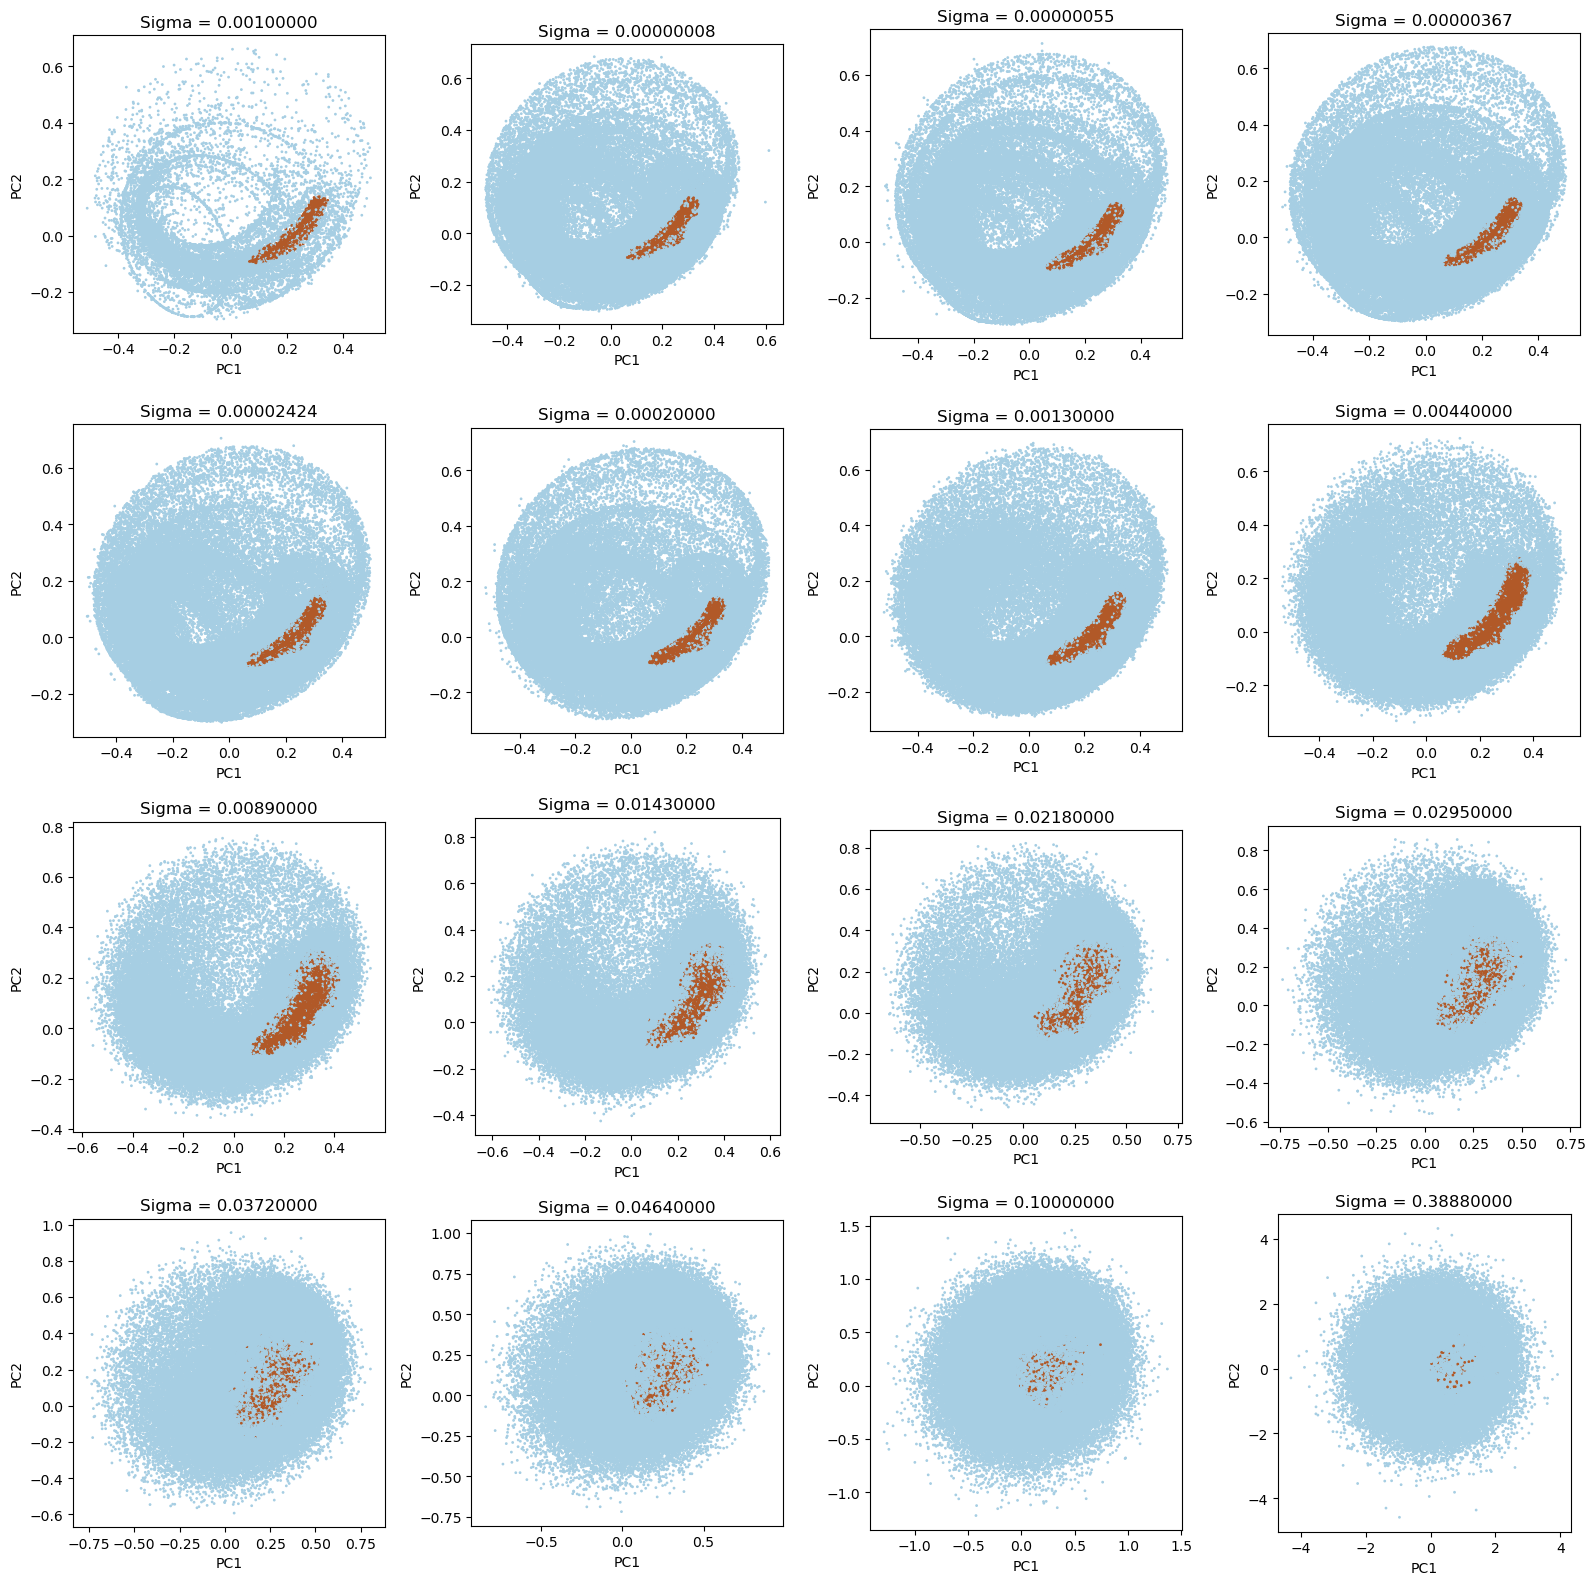

In [25]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

for ax, res in zip(axes, results[::8]):
    sc = ax.scatter(res["coords"][:, 0], res["coords"][:, 1],
                    c=res["labels"], s=1, cmap=cmap)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Sigma = {res['sigma']:.8f}")

# fig.colorbar(sc, ax=axes.tolist(), label="cluster label")
plt.tight_layout()
plt.show()

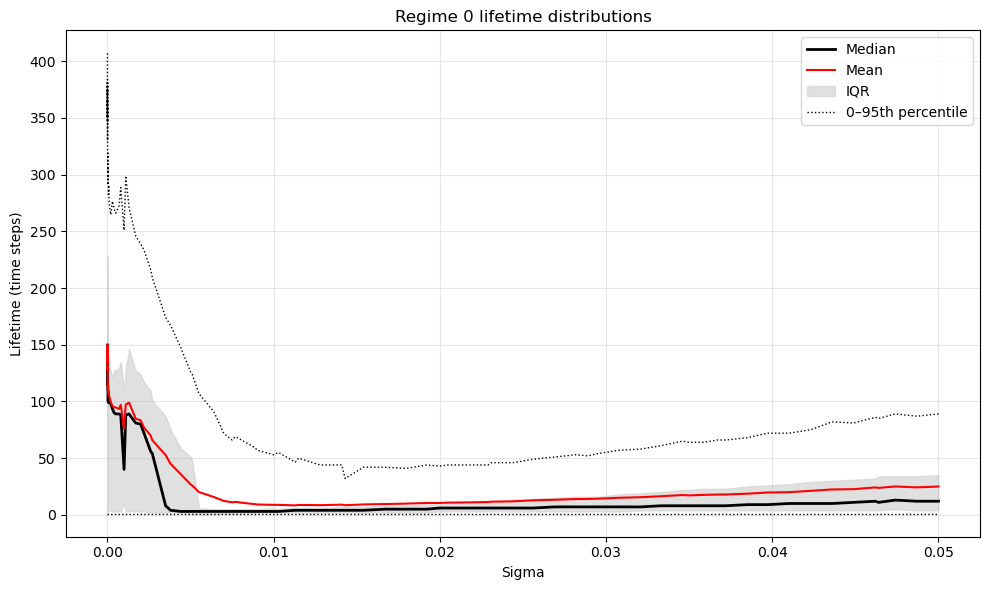

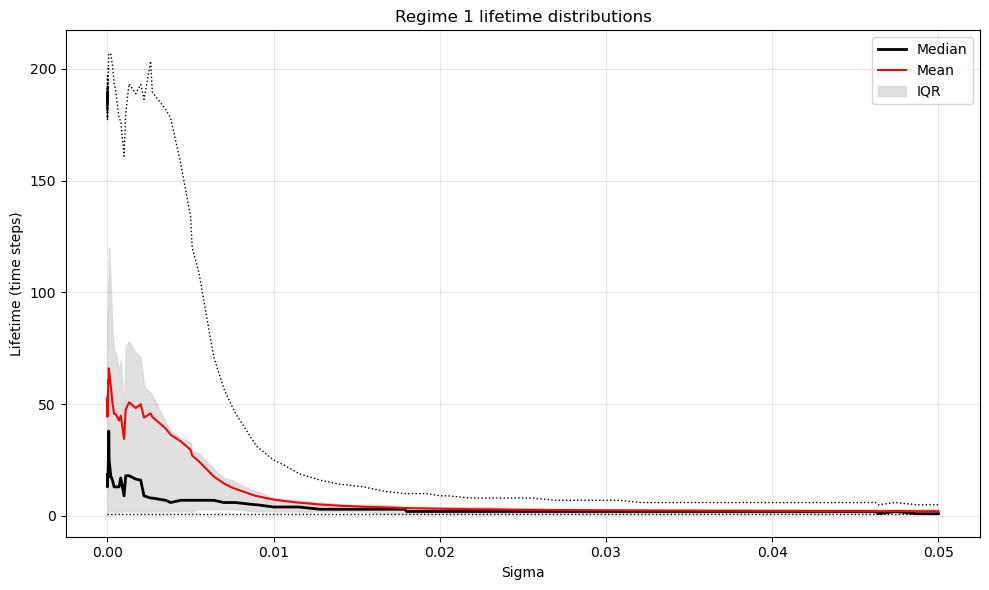

In [26]:
sigma_min = 0.0
sigma_max = 0.05
# escape_results[regime][sigma] = list of lifetimes
escape_results = defaultdict(lambda: defaultdict(list))

for res in results:
    sigma = res["sigma"]
    labels_seq = res["labels"]

    esc_dict = calculate_escape_times(labels_seq, dt=1.0)
    for regime, times in esc_dict.items():
        escape_results[regime][sigma].extend(times)
plot_lifetime_distributions_lines({
    regime: {s: vals for s, vals in escape_results[regime].items()
             if sigma_min <= s <= sigma_max}
    for regime in escape_results
}, regime=0, logx=False)
plot_lifetime_distributions_lines({
    regime: {s: vals for s, vals in escape_results[regime].items()
             if sigma_min <= s <= sigma_max}
    for regime in escape_results
}, regime=1, logx=False)

# Lifetimes from Markov chain

In [9]:
# Back to deterministic case (sigma=0.0)

X_sub = state_vector[inds, :]        # shape (n_subsamples, n_features)

# --- build diffusion-maps matrix (expects samples x features) ---
DMM, A = diffusion_maps_matrix(X_sub, epsilon)

# --- compute clusters from TO ---
res = compute_clusters_from_TO(DMM,
                               n_eig=n_eig,
                               n_clusters=n_clusters,
                               n_init=n_init,
                               eig_indices=eig_indices,
                               random_state=random_state)

### First, escape times (first passage/hitting times)
Starting from a diffusion matrix $P \in \mathbb{R}^{n \times n}$, which is row-stochastic ($P_{ij}$ is the probability of transitioning from state $i$ to state $j$), we first construct a one-step deterministic-then-diffusion operator. For convenience, we transpose to obtain a column-stochastic operator $L = P^\top$, so that distributions evolve as $p_{t+1} = L p_t$. Next, we select a subset of states $B \subset {1,\dots,n}$, representing the “blocking set” of interest. The restriction of $L$ to this set gives a submatrix $Q = L[B,B]$, describing transitions that remain entirely within $B$. 

The $k$-th power $Q^k$ encodes the probability distribution over $B$ after exactly $k$ steps, assuming the system starts in each state of $B$. Summing over all powers, $\sum_{k=0}^{\infty} Q^k$, gives the expected number of visits to each state before leaving $B$. This geometric series converges because $Q$ is sub-stochastic (some probability of leaving $B$ at each step). Multiplying by the vector of ones, $\mathbf{1}$, yields a vector $\mathbf{t} = (\sum_{k=0}^{\infty} Q^k), \mathbf{1}$. Each entry $t_i$ of $\mathbf{t}$ is therefore the expected number of time steps the system spends in $B$ starting from state $i$. Equivalently, we can compute $\mathbf{t}$ using the fundamental matrix formula $\mathbf{t} = (I - Q)^{-1} \mathbf{1}$, which provides the expected first passage or escape time for each state in the blocking set.

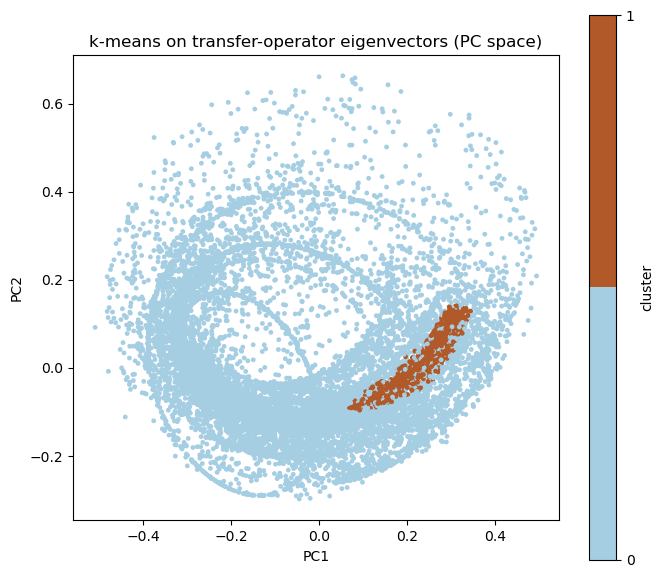

In [10]:
plt.figure(figsize=(7, 6))
num_clusters = len(np.unique(res["labels"]))
cmap = plt.get_cmap("Paired", num_clusters)
sc = plt.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=res["labels"], s=6, cmap=cmap)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('k-means on transfer-operator eigenvectors (PC space)')
cbar = plt.colorbar(sc, ticks=range(num_clusters))
cbar.set_label('cluster')
cbar.set_ticklabels(range(num_clusters))
plt.tight_layout()
plt.show()

In [27]:
# t_escape = expected_escape_times_from_TO(res["L"], res["labels"] == 0)
t_escape_dict = {}

In [46]:
len(calculate_escape_times(res["labels"], dt=1.0)[
    0]) + len(calculate_escape_times(res["labels"], dt=1.0)[1])

1219

In [28]:
for eps in np.linspace(1e-5, 0.002, 10):
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(X_sub, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator and transpose
    L = DMM[1:, :-1].transpose()

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(L, res["labels"] == 0)

    # Store
    t_escape_dict[eps] = t_escape

Processing epsilon = 0.000010
Processing epsilon = 0.000231
Processing epsilon = 0.000452
Processing epsilon = 0.000673
Processing epsilon = 0.000894
Processing epsilon = 0.001116
Processing epsilon = 0.001337
Processing epsilon = 0.001558
Processing epsilon = 0.001779
Processing epsilon = 0.002000


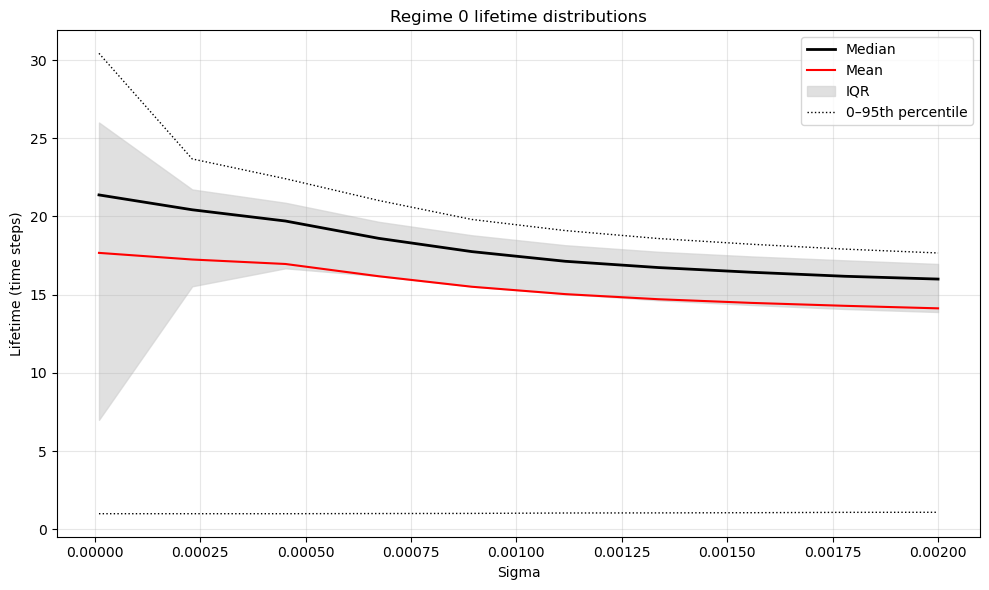

In [26]:
escape_results = {0: {eps: t_escape_dict[eps] for eps in t_escape_dict}}

# Plot for regime 0 (blocking set labeled as 0)
plot_lifetime_distributions_lines(
    {0: {eps: t_escape_dict[eps] for eps in t_escape_dict if eps < 0.005}},
    regime=0, logx=False)

**The above is without transposing L**

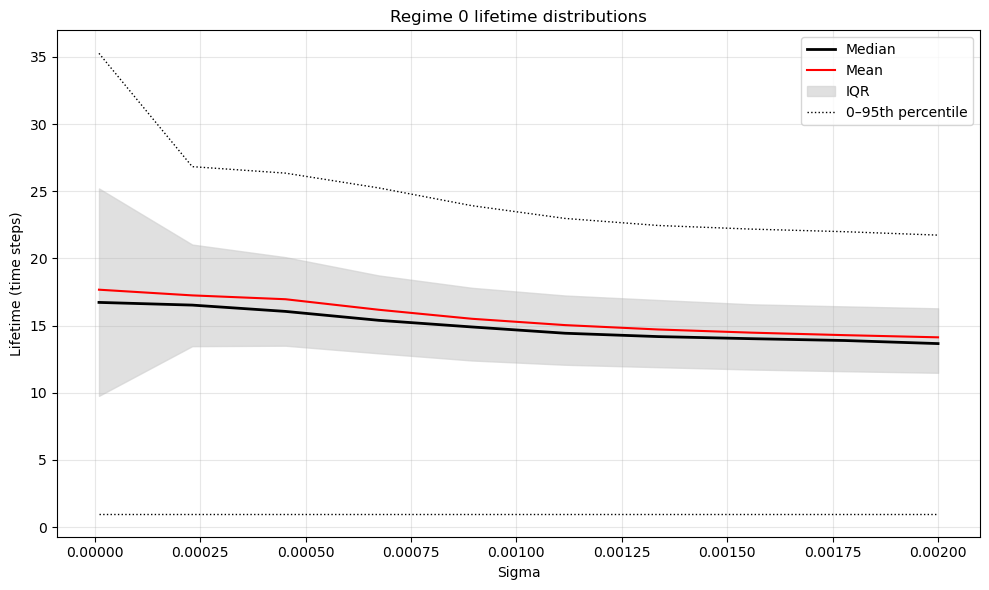

In [29]:
escape_results = {0: {eps: t_escape_dict[eps] for eps in t_escape_dict}}

# Plot for regime 0 (blocking set labeled as 0)
plot_lifetime_distributions_lines(
    {0: {eps: t_escape_dict[eps] for eps in t_escape_dict if eps < 0.005}},
    regime=0, logx=False)

**The above is with transposing L**

In [17]:
escape_rate_dict = {}
for eps in np.linspace(1e-5, 0.002, 10):
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(X_sub, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator and transpose
    L = DMM[1:, :-1].transpose()

    Q = L[res["labels"] == 0, :][:, res["labels"] == 0]
    eigval, _ = eigs(Q, k=1, which='LM')
    # Store
    escape_rate_dict[eps] = eigval.real[0]

Processing epsilon = 0.000010
Processing epsilon = 0.000231
Processing epsilon = 0.000452
Processing epsilon = 0.000673
Processing epsilon = 0.000894
Processing epsilon = 0.001116
Processing epsilon = 0.001337
Processing epsilon = 0.001558
Processing epsilon = 0.001779
Processing epsilon = 0.002000


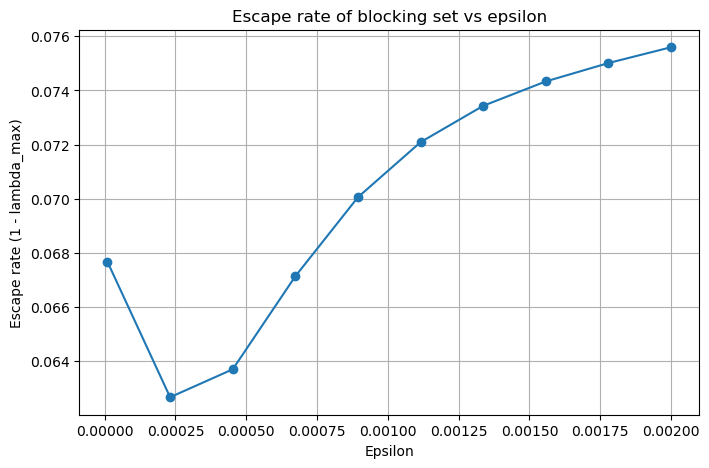

In [18]:
epsilons = np.array(sorted(escape_rate_dict.keys()))
largest_eigs = np.array([escape_rate_dict[eps] for eps in epsilons])

# Compute escape rate per step
escape_rates = 1 - largest_eigs  # r_escape = 1 - lambda_max

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epsilons, escape_rates, marker='o', linestyle='-')
plt.xlabel("Epsilon")
plt.ylabel("Escape rate (1 - lambda_max)")
plt.title("Escape rate of blocking set vs epsilon")
plt.grid(True)
# plt.xscale("log")  # log scale if epsilon spans orders of magnitude
plt.show()